# Explicit vs Implicit — Advection & Diffusion

A complete side-by-side reference for all four scheme combinations.

## The Two Equations

| Equation | Form | Drives |
|----------|------|--------|
| **Advection** | $\dfrac{\partial u}{\partial t} + c\,\dfrac{\partial u}{\partial x} = 0$ | Wave *moving* without shape change |
| **Diffusion** | $\dfrac{\partial u}{\partial t} = \alpha\,\dfrac{\partial^2 u}{\partial x^2}$ | Pulse *spreading* symmetrically |

## What "Explicit" and "Implicit" Mean

**Explicit:** The right-hand side uses values at the *current* time $n$ → solve directly, no system needed.

**Implicit:** The right-hand side uses values at the *next* time $n+1$ → must solve a linear system every step.

```
Explicit:  u^{n+1}_i = f(u^n_{i-1}, u^n_i, u^n_{i+1})      ← simple arithmetic
Implicit:  A · u^{n+1} = u^n                                  ← solve Ax=b each step
```

## Stability Summary

| | Advection Explicit (FTBS) | Advection Implicit (BTCS) | Diffusion Explicit (FTCS) | Diffusion Implicit (BTCS) |
|--|--|--|--|--|
| Stability limit | CFL $\leq 1$ | Unconditional | $r \leq 0.5$ | Unconditional |
| Solve system? | No | Yes (tridiagonal) | No | Yes (tridiagonal) |
| Practical? | ✅ Best for advection | ⚠️ Over-smears | ⚠️ Tiny $\Delta t$ for fine grids | ✅ Best for diffusion |

## Shared Setup — Grid, Initial Condition, Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ── Spatial grid (same for all schemes) ───────────────────────────────────────
L  = 1.0          # domain length
N  = 100          # grid points
dx = L / (N - 1)
x  = np.linspace(0, L, N)

# ── Initial condition: Gaussian pulse ─────────────────────────────────────────
def gaussian(x_arr, center=0.3, sigma=0.05):
    return np.exp(-((x_arr - center) ** 2) / (2 * sigma ** 2))

u0 = gaussian(x)

# ── Helper: build tridiagonal system in scipy banded format ───────────────────
# scipy solve_banded expects shape (3, N):
#   row 0 = superdiagonal  (ab[0, 1:]  = values)
#   row 1 = main diagonal  (ab[1, :]   = values)
#   row 2 = subdiagonal    (ab[2, :-1] = values)
def make_tridiagonal(lower, diag, upper, N):
    ab = np.zeros((3, N))
    ab[0, 1:]  = upper    # superdiagonal
    ab[1, :]   = diag     # main diagonal
    ab[2, :-1] = lower    # subdiagonal
    return ab

print(f"Grid ready: N={N}, dx={dx:.4f}")
print(f"Initial pulse peak at x=0.3, height=1.0")

Grid ready: N=100, dx=0.0101
Initial pulse peak at x=0.3, height=1.0


---
## SCHEME 1 — Advection Explicit (FTBS — Forward Time, Backward Space)

### The equation
$$\frac{u_i^{n+1} - u_i^n}{\Delta t} + c \frac{u_i^n - u_{i-1}^n}{\Delta x} = 0$$

Solving for $u_i^{n+1}$:
$$\boxed{u_i^{n+1} = u_i^n - \underbrace{\frac{c\,\Delta t}{\Delta x}}_{\text{CFL}=\nu}\left(u_i^n - u_{i-1}^n\right)}$$

### Why it works (stability analysis)
- Substitute $u_i^n = g^n e^{ik_m x_i}$ (Fourier mode) into the scheme
- The amplification factor is: $|g| = \sqrt{1 - 2\nu(1-\nu)(1 - \cos\theta)} \leq 1$ **if and only if** $0 \leq \nu \leq 1$
- Outside this range → $|g| > 1$ → every Fourier mode grows → **blow-up**

### Practical rule
- Always use **upwind** direction (FTBS for $c>0$, FTFS for $c<0$)
- Keep CFL $= c\,\Delta t/\Delta x \leq 1$
- CFL = 1 is exact (the wave moves exactly one cell per step) — zero numerical error!

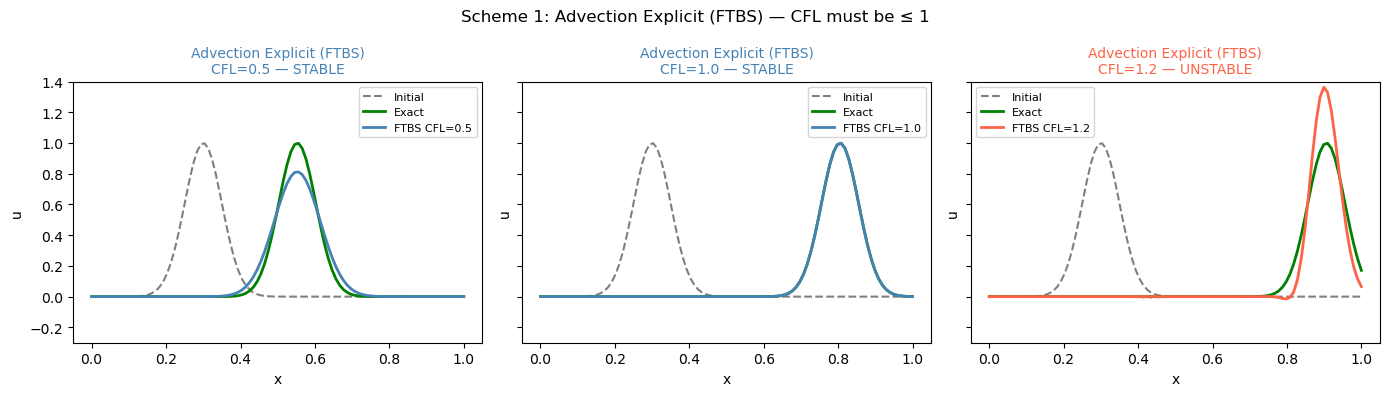

CFL=0.5: stable but numerically diffused (pulse is shorter than exact)
CFL=1.0: exact! wave moves exactly one cell per step — zero error
CFL=1.2: unstable — growing oscillations appear immediately


In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
c   = 1.0   # wave speed (rightward)
nt  = 50    # time steps

# Run for three different CFL values to show stable vs unstable
cfl_tests = [0.5, 1.0, 1.2]   # 1.2 violates the limit
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, cfl in zip(axes, cfl_tests):
    dt = cfl * dx / c
    u  = u0.copy()

    for _ in range(nt):
        # FTBS: u_i - u_{i-1} via np.roll(u, 1) which gives u_{i-1}
        u = u - cfl * (u - np.roll(u, 1))
        u[0] = 0.0   # inlet BC: zero at left wall

    u_exact = gaussian(x, center=0.3 + c * nt * dt)   # exact: pulse shifts right

    stable = "STABLE" if cfl <= 1.0 else "UNSTABLE"
    color  = "steelblue" if cfl <= 1.0 else "tomato"
    ax.plot(x, u0,     "k--", lw=1.5, alpha=0.5, label="Initial")
    ax.plot(x, u_exact, "g-",  lw=2,             label="Exact")
    ax.plot(x, u,       color=color, lw=2,        label=f"FTBS CFL={cfl}")
    ax.set_title(f"Advection Explicit (FTBS)\nCFL={cfl} — {stable}", fontsize=10, color=color)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.set_ylim(-0.3, 1.4); ax.legend(fontsize=8)

plt.suptitle("Scheme 1: Advection Explicit (FTBS) — CFL must be ≤ 1", fontsize=12)
plt.tight_layout(); plt.show()

print("CFL=0.5: stable but numerically diffused (pulse is shorter than exact)")
print("CFL=1.0: exact! wave moves exactly one cell per step — zero error")
print("CFL=1.2: unstable — growing oscillations appear immediately")

---
## SCHEME 2 — Advection Implicit (BTCS — Backward Time, Central Space)

### The equation
Evaluate the spatial derivative at time $n+1$ instead of $n$:
$$\frac{u_i^{n+1} - u_i^n}{\Delta t} + c\frac{u_{i+1}^{n+1} - u_{i-1}^{n+1}}{2\Delta x} = 0$$

Rearranging — unknowns $u^{n+1}$ on both sides → tridiagonal system:
$$-\frac{\nu}{2}\,u_{i-1}^{n+1} + u_i^{n+1} + \frac{\nu}{2}\,u_{i+1}^{n+1} = u_i^n, \quad \nu = \frac{c\,\Delta t}{\Delta x}$$

### Why it's unconditionally stable — but practically limited
- Von Neumann analysis: $|g| = 1/\sqrt{1 + \nu^2 \sin^2\theta} \leq 1$ **for all** $\nu$ ✅
- So *any* $\Delta t$ is stable — you can take giant time steps
- **BUT:** each step adds artificial diffusion proportional to $\nu$
- At large CFL, the wave gets severely smeared — **stable but inaccurate**
- This is why implicit is rarely used alone for pure advection in practice

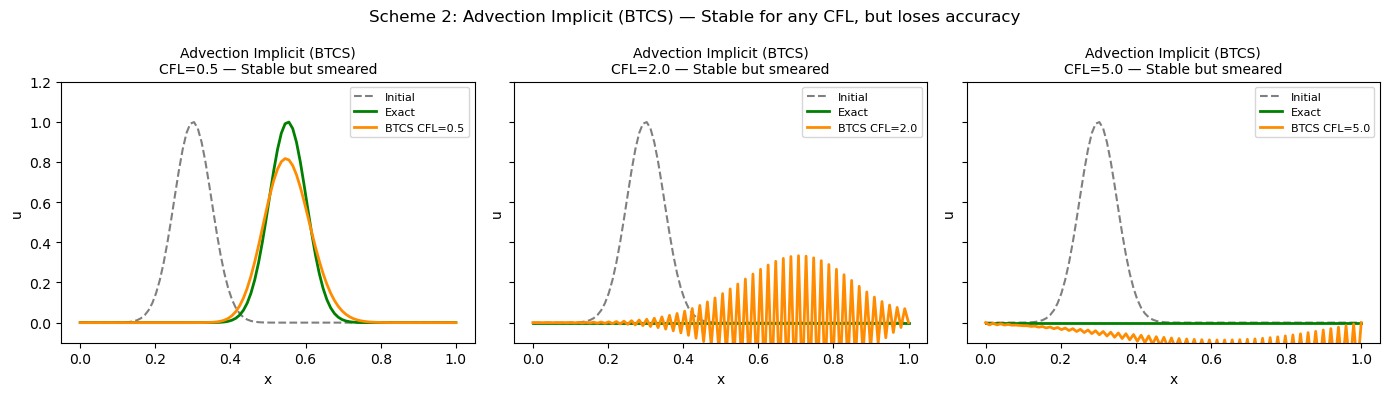

CFL=0.5: reasonably accurate (small steps)
CFL=2.0: stable but noticeably smeared — wave is shorter and wider than exact
CFL=5.0: stable but heavily diffused — barely recognizable as the original pulse

=> Conclusion: Implicit is SAFE for advection, but not ACCURATE at large CFL


In [3]:
def advection_implicit(u0, c, dx, cfl, nt):
    """
    BTCS implicit scheme for advection.
    Uses central space at n+1 -> tridiagonal system.
    Unconditionally stable, but smears at large CFL.
    """
    dt  = cfl * dx / c
    nu  = cfl          # CFL = c*dt/dx
    u   = u0.copy()
    N   = len(u)

    # Build tridiagonal: -nu/2 * u_{i-1} + 1 * u_i + nu/2 * u_{i+1} = u_i^n
    ab = make_tridiagonal(lower=-nu/2, diag=1.0, upper=nu/2, N=N)
    # Dirichlet BCs: u[0] = 0, u[-1] = 0
    ab[1, 0]  = 1.0; ab[0, 1]  = 0.0
    ab[1, -1] = 1.0; ab[2, -2] = 0.0

    for _ in range(nt):
        rhs      = u.copy()
        rhs[0]   = 0.0
        rhs[-1]  = 0.0
        u = solve_banded((1, 1), ab, rhs)
    return u

# ── Compare at different CFL values ───────────────────────────────────────────
cfl_tests = [0.5, 2.0, 5.0]   # implicit can handle CFL >> 1
nt_adv    = 50
c         = 1.0

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, cfl in zip(axes, cfl_tests):
    dt       = cfl * dx / c
    u_im     = advection_implicit(u0, c, dx, cfl, nt_adv)
    u_exact  = gaussian(x, center=0.3 + c * nt_adv * dt)

    ax.plot(x, u0,      "k--", lw=1.5, alpha=0.5, label="Initial")
    ax.plot(x, u_exact, "g-",  lw=2,              label="Exact")
    ax.plot(x, u_im,    "darkorange", lw=2,        label=f"BTCS CFL={cfl}")
    ax.set_title(f"Advection Implicit (BTCS)\nCFL={cfl} — Stable but smeared", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    ax.set_ylim(-0.1, 1.2); ax.legend(fontsize=8)

plt.suptitle("Scheme 2: Advection Implicit (BTCS) — Stable for any CFL, but loses accuracy", fontsize=12)
plt.tight_layout(); plt.show()

print("CFL=0.5: reasonably accurate (small steps)")
print("CFL=2.0: stable but noticeably smeared — wave is shorter and wider than exact")
print("CFL=5.0: stable but heavily diffused — barely recognizable as the original pulse")
print()
print("=> Conclusion: Implicit is SAFE for advection, but not ACCURATE at large CFL")

---
## SCHEME 3 — Diffusion Explicit (FTCS — Forward Time, Central Space)

### The equation
$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta x^2}$$

Solving for $u_i^{n+1}$, letting $r = \alpha\Delta t/\Delta x^2$:
$$\boxed{u_i^{n+1} = u_i^n + r\left(u_{i+1}^n - 2u_i^n + u_{i-1}^n\right)}$$

### Why the stability limit is $r \leq 0.5$
Substituting a Fourier mode, the amplification factor is:
$$g = 1 - 4r\sin^2\!\left(\frac{\theta}{2}\right)$$

For stability we need $|g| \leq 1$, which means $-1 \leq g \leq 1$.
The tightest constraint comes from the worst-case mode ($\sin^2=1$):
$$g = 1 - 4r \geq -1 \implies r \leq \frac{1}{2}$$

### The cruel grid refinement cost
If you halve $\Delta x$ (finer grid):
- $\Delta x \to \Delta x/2$, so $\Delta x^2 \to \Delta x^2/4$
- To keep $r = \alpha\Delta t/\Delta x^2 \leq 0.5$, you need $\Delta t \to \Delta t/4$
- **4× more time steps just to halve the grid!** For 3D: 8× more steps. This makes explicit diffusion very expensive on fine grids.

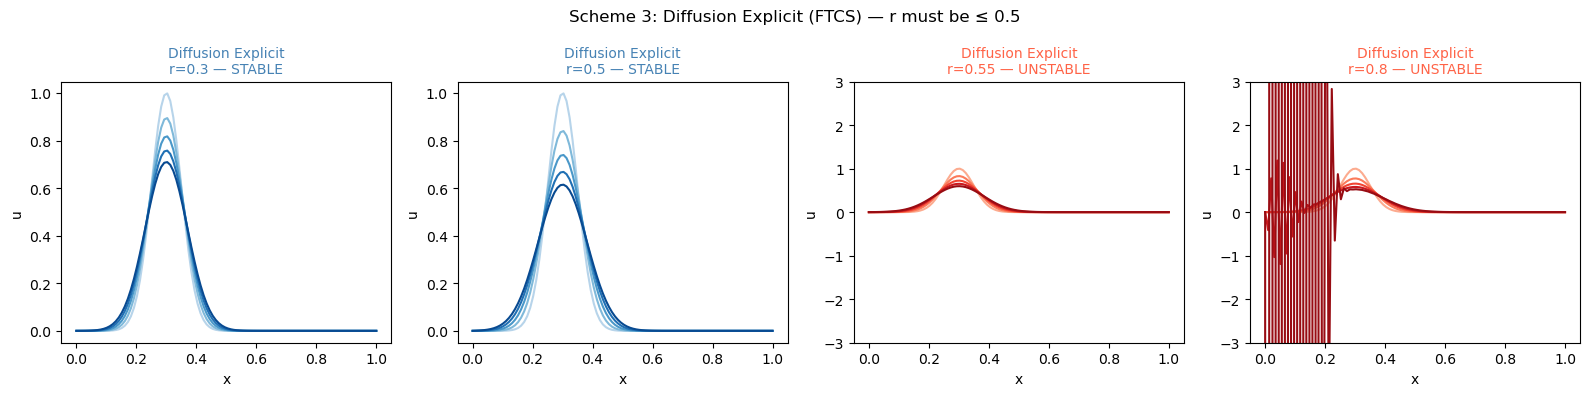

Grid refinement cost (keeping r=0.4 fixed, alpha=0.01):
       N          dx            dt     nt needed for T=0.1
      50     0.02041      0.016660                       6
     100     0.01010      0.004081                      24
     200     0.00503      0.001010                      99
     400     0.00251      0.000251                     398


In [4]:
def diffusion_explicit(u0, alpha, dx, r, nt, save_every=None):
    """
    FTCS explicit scheme for 1D diffusion.
    Stable only when r = alpha*dt/dx^2 <= 0.5
    """
    dt = r * dx**2 / alpha
    u  = u0.copy()
    snapshots = [(0, u.copy())]

    for n in range(1, nt + 1):
        # Central difference: u_{i+1} - 2*u_i + u_{i-1}
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
        u_new[0]    = 0.0   # Dirichlet BC left
        u_new[-1]   = 0.0   # Dirichlet BC right
        u = u_new
        if save_every and n % save_every == 0:
            snapshots.append((n, u.copy()))

    return u, snapshots, dt

# ── Part A: show the r <= 0.5 stability cliff ─────────────────────────────────
alpha = 0.01
r_values = [0.3, 0.5, 0.55, 0.8]
nt_stab  = 40

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, r_test in zip(axes, r_values):
    u_final, snaps, dt_test = diffusion_explicit(u0, alpha, dx, r_test, nt_stab, save_every=10)
    stable = r_test <= 0.5
    color  = "steelblue" if stable else "tomato"
    label  = "STABLE" if stable else "UNSTABLE"
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(snaps))) if stable else plt.cm.Reds(np.linspace(0.3, 0.9, len(snaps)))
    for (step, u_snap), c_line in zip(snaps, colors):
        ax.plot(x, u_snap, color=c_line, lw=1.5)
    ax.set_title(f"Diffusion Explicit\nr={r_test} — {label}", fontsize=10, color=color)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    if not stable:
        ax.set_ylim(-3, 3)

plt.suptitle("Scheme 3: Diffusion Explicit (FTCS) — r must be ≤ 0.5", fontsize=12)
plt.tight_layout(); plt.show()

# ── Part B: show the grid refinement cost ─────────────────────────────────────
print("Grid refinement cost (keeping r=0.4 fixed, alpha=0.01):")
print(f"{'N':>8}  {'dx':>10}  {'dt':>12}  {'nt needed for T=0.1':>22}")
for N_test in [50, 100, 200, 400]:
    dx_test = L / (N_test - 1)
    dt_test = 0.4 * dx_test**2 / alpha
    nt_test = int(0.1 / dt_test)
    print(f"{N_test:>8}  {dx_test:>10.5f}  {dt_test:>12.6f}  {nt_test:>22}")

---
## SCHEME 4 — Diffusion Implicit (BTCS — Backward Time, Central Space)

### The equation
Evaluate the spatial term at time $n+1$:
$$\frac{u_i^{n+1} - u_i^n}{\Delta t} = \alpha \frac{u_{i+1}^{n+1} - 2u_i^{n+1} + u_{i-1}^{n+1}}{\Delta x^2}$$

Rearranging — every term involving $u^{n+1}$ goes to the left side:
$$-r\,u_{i-1}^{n+1} + (1+2r)\,u_i^{n+1} - r\,u_{i+1}^{n+1} = u_i^n$$

This is a tridiagonal system $A\mathbf{u}^{n+1} = \mathbf{u}^n$ where:

$$A = \begin{pmatrix} 1{+}2r & -r \\ -r & 1{+}2r & -r \\ & \ddots & \ddots & \ddots \\ & & -r & 1{+}2r \end{pmatrix}$$

### Why it's unconditionally stable
Amplification factor: $g = \dfrac{1}{1 + 4r\sin^2(\theta/2)}$

Since the denominator $\geq 1$ always, we get $|g| \leq 1$ **for any $r$**. No constraint on $\Delta t$.

### The practical advantage — take large time steps freely
You can use $r = 10$, $r = 100$, any value. Each step costs one tridiagonal solve $O(N)$ — very fast.
This is the **standard scheme** for viscous terms in real CFD solvers.

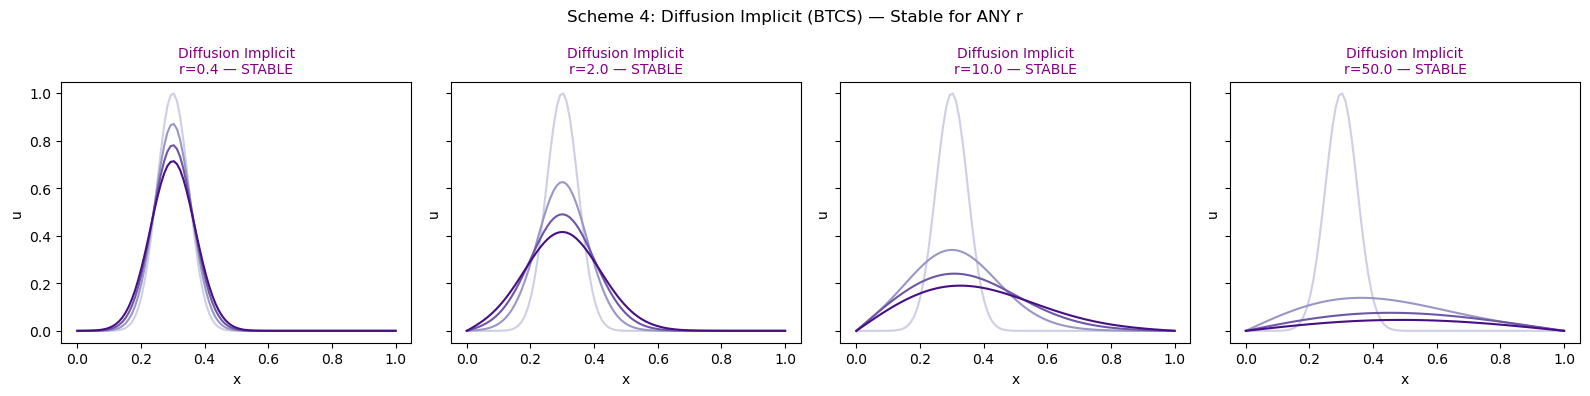

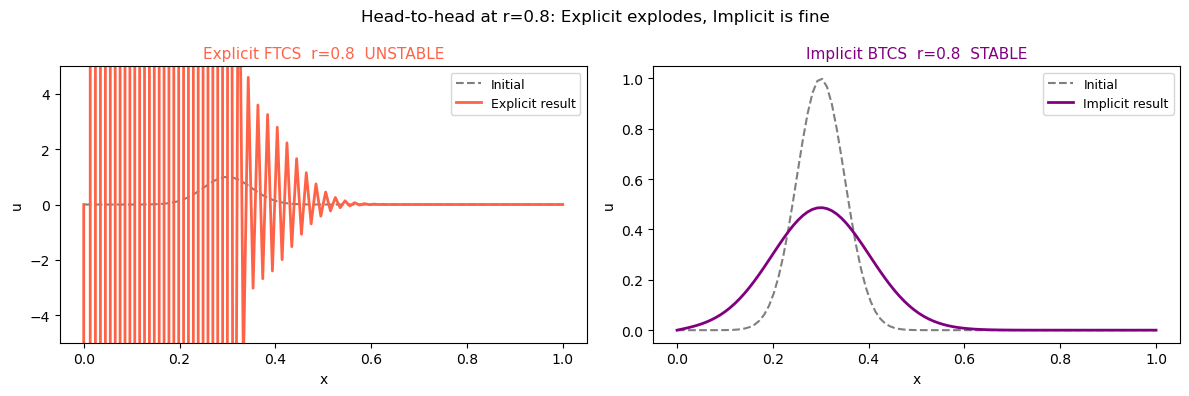

Implicit BTCS solved the system stably at r=0.8 — no tricks needed.


In [5]:
def diffusion_implicit(u0, alpha, dx, r, nt, save_every=None):
    """
    BTCS implicit scheme for 1D diffusion.
    Solves tridiagonal system A*u^{n+1} = u^n at each step.
    Unconditionally stable — any r works.
    """
    dt = r * dx**2 / alpha
    u  = u0.copy()
    N  = len(u)
    snapshots = [(0, u.copy())]

    # Build tridiagonal matrix (constant — only built once!)
    # Main diagonal: 1+2r,  off-diagonals: -r
    ab = make_tridiagonal(lower=-r, diag=1.0 + 2*r, upper=-r, N=N)
    # Dirichlet BCs: fix first and last rows
    ab[1, 0]  = 1.0; ab[0, 1]  = 0.0
    ab[1, -1] = 1.0; ab[2, -2] = 0.0

    for n in range(1, nt + 1):
        rhs      = u.copy()
        rhs[0]   = 0.0
        rhs[-1]  = 0.0
        u = solve_banded((1, 1), ab, rhs)
        if save_every and n % save_every == 0:
            snapshots.append((n, u.copy()))

    return u, snapshots, dt

# ── Part A: implicit is stable even for huge r ────────────────────────────────
alpha = 0.01
r_values_im = [0.4, 2.0, 10.0, 50.0]   # explicit would explode for r > 0.5
nt_im = 30

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, r_test in zip(axes, r_values_im):
    u_final, snaps, dt_test = diffusion_implicit(u0, alpha, dx, r_test, nt_im, save_every=10)
    colors_plot = plt.cm.Purples(np.linspace(0.3, 0.95, len(snaps)))
    for (step, u_snap), c_line in zip(snaps, colors_plot):
        ax.plot(x, u_snap, color=c_line, lw=1.5)
    ax.set_title(f"Diffusion Implicit\nr={r_test} — STABLE", fontsize=10, color="purple")
    ax.set_xlabel("x"); ax.set_ylabel("u")

plt.suptitle("Scheme 4: Diffusion Implicit (BTCS) — Stable for ANY r", fontsize=12)
plt.tight_layout(); plt.show()

# ── Part B: head-to-head at r=0.8 (explicit fails, implicit wins) ─────────────
r_test  = 0.8
nt_comp = 50

u_ex, _, dt_ex = diffusion_explicit(u0, alpha, dx, r_test, nt_comp)
u_im, _, dt_im = diffusion_implicit(u0, alpha, dx, r_test, nt_comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, u_scheme, title, col in zip(
    axes,
    [u_ex, u_im],
    [f"Explicit FTCS  r={r_test}  UNSTABLE", f"Implicit BTCS  r={r_test}  STABLE"],
    ["tomato", "purple"]
):
    ax.plot(x, u0,       "k--", lw=1.5, alpha=0.5, label="Initial")
    ax.plot(x, u_scheme, color=col, lw=2,           label=title.split()[0]+" result")
    ax.set_title(title, fontsize=11, color=col)
    ax.set_xlabel("x"); ax.set_ylabel("u")
    if "UNSTABLE" in title:
        ax.set_ylim(-5, 5)
    ax.legend(fontsize=9)

plt.suptitle(f"Head-to-head at r={r_test}: Explicit explodes, Implicit is fine", fontsize=12)
plt.tight_layout(); plt.show()

print("Implicit BTCS solved the system stably at r=0.8 — no tricks needed.")

---
## Final Comparison — All Four Schemes Together

Same initial condition, same total simulation time $T$, same grid.

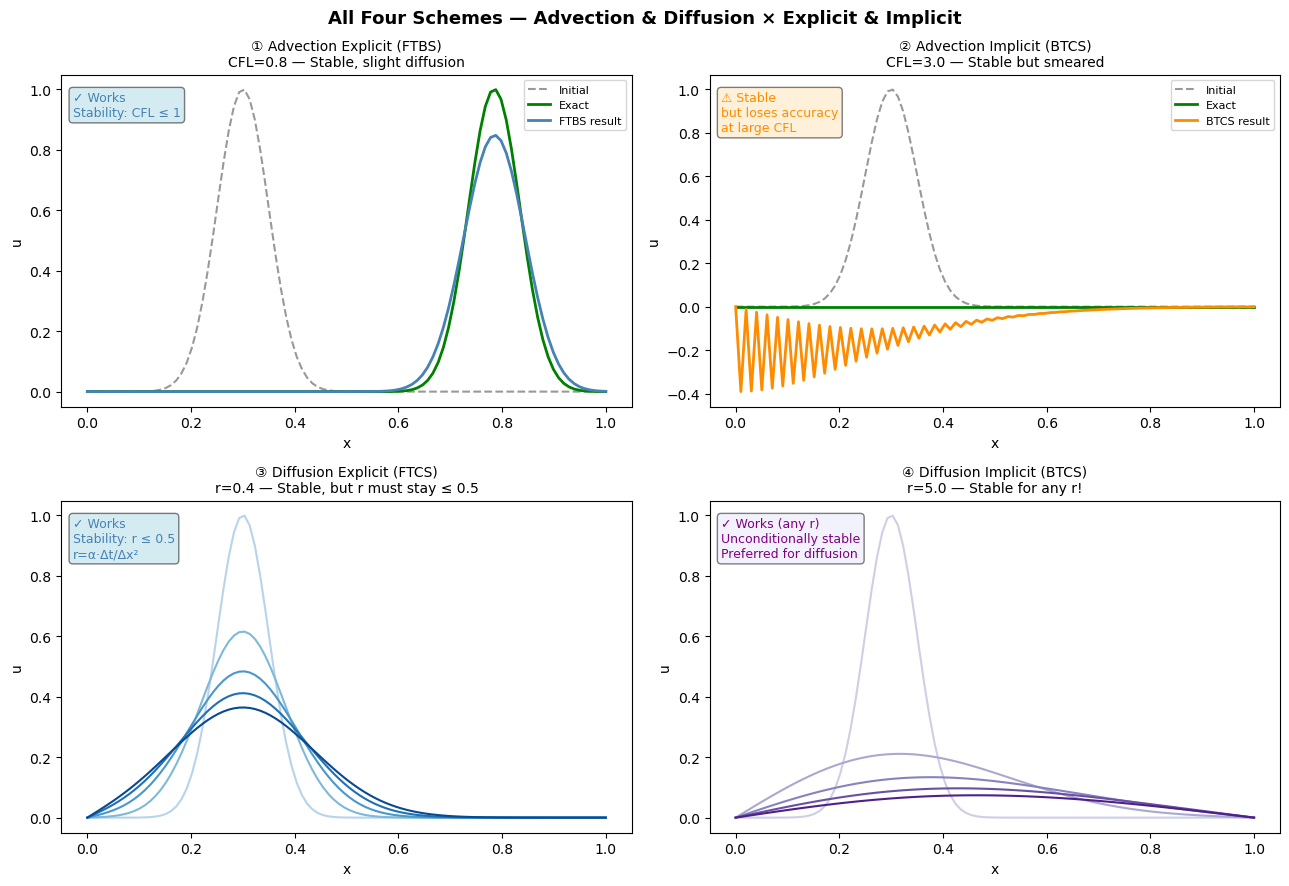

  DECISION GUIDE
  Advection + Explicit  → USE  (fast, accurate, CFL ≤ 1)
  Advection + Implicit  → AVOID (stable but smears wave)
  Diffusion + Explicit  → OK for coarse grids (r ≤ 0.5)
  Diffusion + Implicit  → PREFERRED (any r, unconditional)

In Navier-Stokes (Module 2):
  Convection term → treat EXPLICITLY (upwind)
  Viscous term    → treat IMPLICITLY  (tridiagonal)


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── 1. Advection Explicit (FTBS, CFL=0.8) ─────────────────────────────────────
ax = axes[0, 0]
c_adv = 1.0; cfl = 0.8; nt_adv = 60
dt_adv = cfl * dx / c_adv
u = u0.copy()
for _ in range(nt_adv):
    u = u - cfl * (u - np.roll(u, 1))
    u[0] = 0.0
u_exact = gaussian(x, center=0.3 + c_adv * nt_adv * dt_adv)
ax.plot(x, u0,      "k--", lw=1.5, alpha=0.4, label="Initial")
ax.plot(x, u_exact, "g-",  lw=2,              label="Exact")
ax.plot(x, u,       "steelblue", lw=2,         label="FTBS result")
ax.set_title(f"① Advection Explicit (FTBS)\nCFL={cfl} — Stable, slight diffusion", fontsize=10)
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.legend(fontsize=8)
ax.text(0.02, 0.95, "✓ Works\nStability: CFL ≤ 1", transform=ax.transAxes,
        fontsize=9, va="top", color="steelblue",
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5))

# ── 2. Advection Implicit (BTCS, CFL=3.0) ─────────────────────────────────────
ax = axes[0, 1]
cfl_im = 3.0
dt_im  = cfl_im * dx / c_adv
u_im_adv = advection_implicit(u0, c_adv, dx, cfl_im, nt_adv)
u_exact_im = gaussian(x, center=0.3 + c_adv * nt_adv * dt_im)
ax.plot(x, u0,          "k--", lw=1.5, alpha=0.4, label="Initial")
ax.plot(x, u_exact_im,  "g-",  lw=2,              label="Exact")
ax.plot(x, u_im_adv,    "darkorange", lw=2,        label="BTCS result")
ax.set_title(f"② Advection Implicit (BTCS)\nCFL={cfl_im} — Stable but smeared", fontsize=10)
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.legend(fontsize=8)
ax.text(0.02, 0.95, "⚠ Stable\nbut loses accuracy\nat large CFL", transform=ax.transAxes,
        fontsize=9, va="top", color="darkorange",
        bbox=dict(boxstyle="round", facecolor="moccasin", alpha=0.5))

# ── 3. Diffusion Explicit (FTCS, r=0.4) ───────────────────────────────────────
ax = axes[1, 0]
alpha_d = 0.01; r_d = 0.4; nt_d = 200
u_ex_diff, snaps_ex, dt_d = diffusion_explicit(u0, alpha_d, dx, r_d, nt_d, save_every=50)
colors_d = plt.cm.Blues(np.linspace(0.3, 0.9, len(snaps_ex)))
for (step, u_snap), c_line in zip(snaps_ex, colors_d):
    ax.plot(x, u_snap, color=c_line, lw=1.5)
ax.set_title(f"③ Diffusion Explicit (FTCS)\nr={r_d} — Stable, but r must stay ≤ 0.5", fontsize=10)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.text(0.02, 0.95, f"✓ Works\nStability: r ≤ 0.5\nr=α·Δt/Δx²", transform=ax.transAxes,
        fontsize=9, va="top", color="steelblue",
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.5))

# ── 4. Diffusion Implicit (BTCS, r=5.0) ───────────────────────────────────────
ax = axes[1, 1]
r_large = 5.0
u_im_diff, snaps_im, dt_im_d = diffusion_implicit(u0, alpha_d, dx, r_large, nt_d, save_every=50)
colors_p = plt.cm.Purples(np.linspace(0.3, 0.9, len(snaps_im)))
for (step, u_snap), c_line in zip(snaps_im, colors_p):
    ax.plot(x, u_snap, color=c_line, lw=1.5)
ax.set_title(f"④ Diffusion Implicit (BTCS)\nr={r_large} — Stable for any r!", fontsize=10)
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.text(0.02, 0.95, "✓ Works (any r)\nUnconditionally stable\nPreferred for diffusion", transform=ax.transAxes,
        fontsize=9, va="top", color="purple",
        bbox=dict(boxstyle="round", facecolor="lavender", alpha=0.5))

plt.suptitle("All Four Schemes — Advection & Diffusion × Explicit & Implicit", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Decision summary ──────────────────────────────────────────────────────────
print("=" * 60)
print("  DECISION GUIDE")
print("=" * 60)
print("  Advection + Explicit  → USE  (fast, accurate, CFL ≤ 1)")
print("  Advection + Implicit  → AVOID (stable but smears wave)")
print("  Diffusion + Explicit  → OK for coarse grids (r ≤ 0.5)")
print("  Diffusion + Implicit  → PREFERRED (any r, unconditional)")
print("=" * 60)
print()
print("In Navier-Stokes (Module 2):")
print("  Convection term → treat EXPLICITLY (upwind)")
print("  Viscous term    → treat IMPLICITLY  (tridiagonal)")